In [ ]:
import io
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set_theme(style="whitegrid")

uploaded = files.upload()
zip_name = next(iter(uploaded))

with zipfile.ZipFile(io.BytesIO(uploaded[zip_name])) as z:
    df = pd.read_csv(
        z.open("JFF_formatted_public_release_values.csv"),
        encoding="cp1252",
        low_memory=False
    )
    variables = pd.read_excel(
        z.open("JFF_formatted_public_release_codebook.xlsx"),
        sheet_name="variables"
    )
    labels = pd.read_excel(
        z.open("JFF_formatted_public_release_codebook.xlsx"),
        sheet_name="labels"
    )

print(f"{len(df):,} respondents × {df.shape[1]} columns")
display(df.head())
display(variables.head())

Saving American-Job-Quality-Survey-Data-2025.zip to American-Job-Quality-Survey-Data-2025.zip
18,429 respondents × 153 columns


,ENTITY_ID,SAMPLE,MODE,RESPONDENT_DATE,EndDate,S1,Q1,Q2,Q3,Q4,...,RACE6,RACE7,MARITAL_STATUS,EDUCATION,STATE,REGION,DIVISION,WORKER_TYPE,W2_STATUS,WEIGHT
0,4398199396,4,2,1/28/2025,,,7,7,2,6,...,,7,3,2,MA,1,1,1,1,0.988427
1,4398199398,4,2,1/28/2025,,,10,8,1,10,...,,7,2,5,MA,1,1,1,1,0.184232
2,4398199412,4,2,1/23/2025,,,8,8,1,8,...,,7,5,6,MA,1,1,1,1,0.368465
3,4398199417,4,2,1/30/2025,,,8,8,2,9,...,,7,2,2,MA,1,1,4,2,3.341439
4,4398199431,3,1,,1/16/2025 6:47:11,1,6,7,2,5,...,,,5,3,MA,1,1,1,1,1.515829


,variable,label
0,ENTITY_ID,ENTITY_ID
1,SAMPLE,Sample
2,MODE,Mode
3,RESPONDENT_DATE,Recorded Date
4,EndDate,End Date


In [ ]:
questions_to_review = [
    "Q4", "Q6", "Q6_CODED", "Q20", "Q28", "Q33A",
    "Q33C", "Q33F", "Q33G", "Q33I", "Q40",
    "Q51", "Q57", "Q65", "WEIGHT"
]

display(
    variables[variables["variable"].isin(questions_to_review)]
    [["variable", "label"]]
    .style.set_properties(subset=["label"], **{"white-space": "pre-wrap"})
)

# Change this variable to inspect its response codes.
variable_to_inspect = "Q6"
display(labels[labels["variable"] == variable_to_inspect])

,variable,label
9,Q4,"Overall, how satisfied are you with your job? If you have more than one job, please answer in terms of the job on which you work the most hours."
11,Q6,"For the following questions, please think only about your main job -- the job on which you work the most hours. What kind of work do YOU do in this main job? That is, what is your occupation? - Selected Choice"
12,Q6_CODED,"For the following questions, please think only about your main job -- the job on which you work the most hours. What kind of work do YOU do in this main job? That is, what is your occupation? Something else (please specify (Coded)"
32,Q20,"How many hours do you usually work PER WEEK on your main job? If you are self-employed, think about all of the time you spend working in this job, including operating your business and working with customers/clients."
49,Q28,"Please think of the number of hours you work and the money you earn in your main job, including any regular overtime. If you had to choose among the following work situations, which of the following would you prefer?"
58,Q33A,You have the freedom to decide how you do your work.
60,Q33C,Your job allows you to learn new things.
63,Q33F,You feel supported at work.
64,Q33G,You feel like you belong at work.
66,Q33I,You are paid fairly for the work you do.


,variable,value,label
52,Q6,-98.0,No response
53,Q6,1.0,Management
54,Q6,2.0,Business and financial operations
55,Q6,3.0,Computer and mathematical
56,Q6,4.0,Architecture and engineering
57,Q6,5.0,"Life, physical, and social science"
58,Q6,6.0,Community and social service
59,Q6,7.0,Legal
60,Q6,8.0,Educational instruction and library
61,Q6,9.0,"Arts, design, entertainment, sports, and media"


In [ ]:
eda = df.copy()

# The codebook identifies -98 as "No response."
# For select-all-that-apply questions, -99 means "Not selected,"
# so do NOT replace every -99 with missing.
numeric_cols = eda.select_dtypes(include="number").columns
eda[numeric_cols] = eda[numeric_cols].replace(-98, np.nan)

# Convert selected analysis fields to numeric in case CSV parsing
# left a column as text.
analysis_cols = [
    "Q4", "Q6", "Q6_CODED", "Q20", "Q28", "Q40",
    "Q51", "Q57", "Q65", "WEIGHT"
] + [f"Q33{letter}" for letter in "ABCDEFGHIJ"]

for col in analysis_cols:
    eda[col] = pd.to_numeric(eda[col], errors="coerce")

print("Unique respondents:", eda["ENTITY_ID"].nunique())
print("Duplicate respondent IDs:", eda["ENTITY_ID"].duplicated().sum())
print("Survey dates:", eda["RESPONDENT_DATE"].dropna().head().tolist())

Unique respondents: 18429
Duplicate respondent IDs: 0
Survey dates: ['1/28/2025', '1/28/2025', '1/23/2025', '1/30/2025', ' ']


,question,missing_n,missing_pct
2,Q6_CODED,15981,86.7
7,Q57,14374,78.0
3,Q20,638,3.5
5,Q40,357,1.9
4,Q28,173,0.9
13,Q33D,159,0.9
15,Q33F,151,0.8
16,Q33G,147,0.8
14,Q33E,141,0.8
18,Q33I,140,0.8


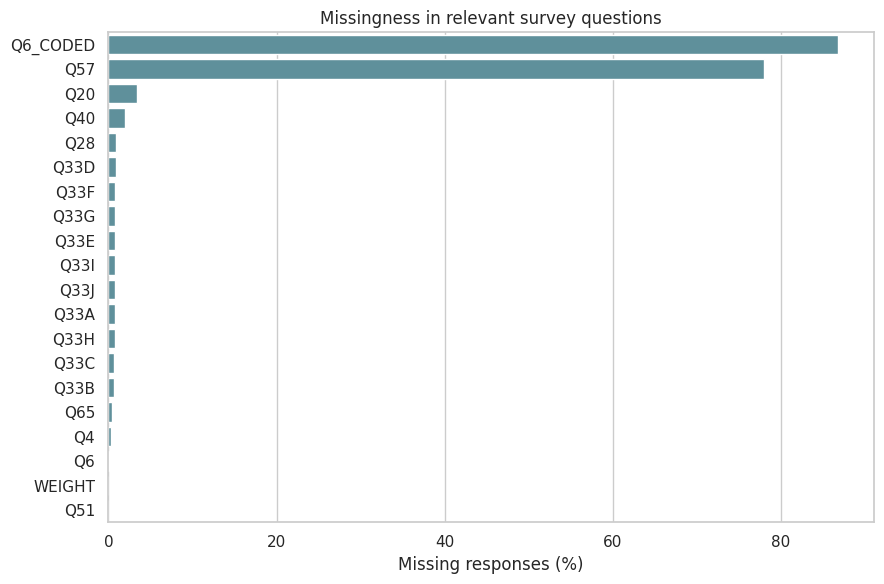

In [ ]:
focus_cols = [
    "Q4", "Q6", "Q6_CODED", "Q20", "Q28", "Q40",
    "Q51", "Q57", "Q65", "WEIGHT"
] + [f"Q33{letter}" for letter in "ABCDEFGHIJ"]

missing = pd.DataFrame({
    "question": focus_cols,
    "missing_n": [eda[col].isna().sum() for col in focus_cols],
    "missing_pct": [eda[col].isna().mean() * 100 for col in focus_cols]
}).sort_values("missing_pct", ascending=False)

display(missing.round(1))

plt.figure(figsize=(9, 6))
sns.barplot(data=missing, x="missing_pct", y="question", color="#5596a5")
plt.xlabel("Missing responses (%)")
plt.ylabel("")
plt.title("Missingness in relevant survey questions")
plt.tight_layout()
plt.show()

,satisfaction_score,respondents
0,0.0,264
1,1.0,217
2,2.0,396
3,3.0,728
4,4.0,878
5,5.0,1761
6,6.0,2396
7,7.0,4096
8,8.0,4219
9,9.0,2188


Mean: 6.77
Median: 7.0


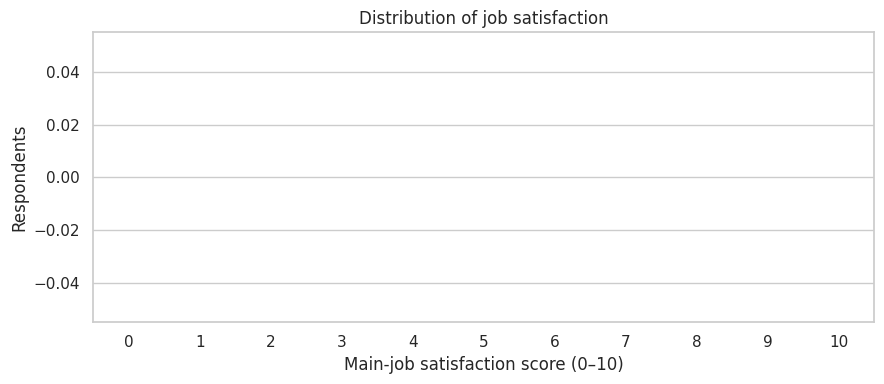

In [ ]:
satisfaction = eda["Q4"].dropna()

display(
    satisfaction.value_counts()
    .sort_index()
    .rename_axis("satisfaction_score")
    .reset_index(name="respondents")
)

print("Mean:", round(satisfaction.mean(), 2))
print("Median:", satisfaction.median())

plt.figure(figsize=(9, 4))
sns.countplot(x=eda["Q4"], order=range(11), color="#6574ad")
plt.xlabel("Main-job satisfaction score (0–10)")
plt.ylabel("Respondents")
plt.title("Distribution of job satisfaction")
plt.tight_layout()
plt.show()

In [ ]:
occupation_labels = (
    labels[labels["variable"] == "Q6"]
    .dropna(subset=["value"])
    .set_index("value")["label"]
    .to_dict()
)

# Q6_CODED applies to some "Something else" answers.
# Use it only when Q6 lacks a usable occupation category.
eda["occupation_group"] = eda["Q6"]
eda["occupation_group"] = eda["occupation_group"].fillna(eda["Q6_CODED"])

occupation_summary = (
    eda.groupby("occupation_group", dropna=False)
    .agg(
        respondents=("ENTITY_ID", "size"),
        mean_satisfaction=("Q4", "mean"),
        satisfaction_available=("Q4", "count")
    )
    .reset_index()
    .sort_values("respondents", ascending=False)
)

occupation_summary["occupation_name"] = (
    occupation_summary["occupation_group"].map(occupation_labels)
    .fillna("Missing / unmapped")
)

display(
    occupation_summary[
        ["occupation_group", "occupation_name", "respondents",
         "satisfaction_available", "mean_satisfaction"]
    ].round(2)
)

print(
    "Respondents with both satisfaction and occupation:",
    eda[["Q4", "occupation_group"]].notna().all(axis=1).sum()
)

/tmp/ipykernel_1191/4052123820.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  eda["occupation_group"] = eda["Q6"]


,occupation_group,occupation_name,respondents,satisfaction_available,mean_satisfaction
7,8.0,Educational instruction and library,2028,2026,6.95
0,1.0,Management,1984,1976,6.91
1,2.0,Business and financial operations,1907,1901,6.84
17,18.0,Office and administrative support,1472,1470,6.63
2,3.0,Computer and mathematical,1263,1263,6.81
16,17.0,Sales and related,1208,1202,6.41
9,10.0,Healthcare practitioners,953,953,6.99
11,12.0,Healthcare support,735,732,6.49
22,23.0,Transportation and material moving,692,690,6.50
8,9.0,"Arts, design, entertainment, sports, and media",652,649,6.88


Respondents with both satisfaction and occupation: 18364


,aspect,available_n,spearman_with_satisfaction
0,Freedom in how work is done,18245,-0.349
1,Opportunity to learn,18246,-0.369
2,Feeling supported,18230,-0.521
3,Sense of belonging,18234,-0.559
4,Fair pay,18241,-0.428
5,Physical safety,18244,-0.312


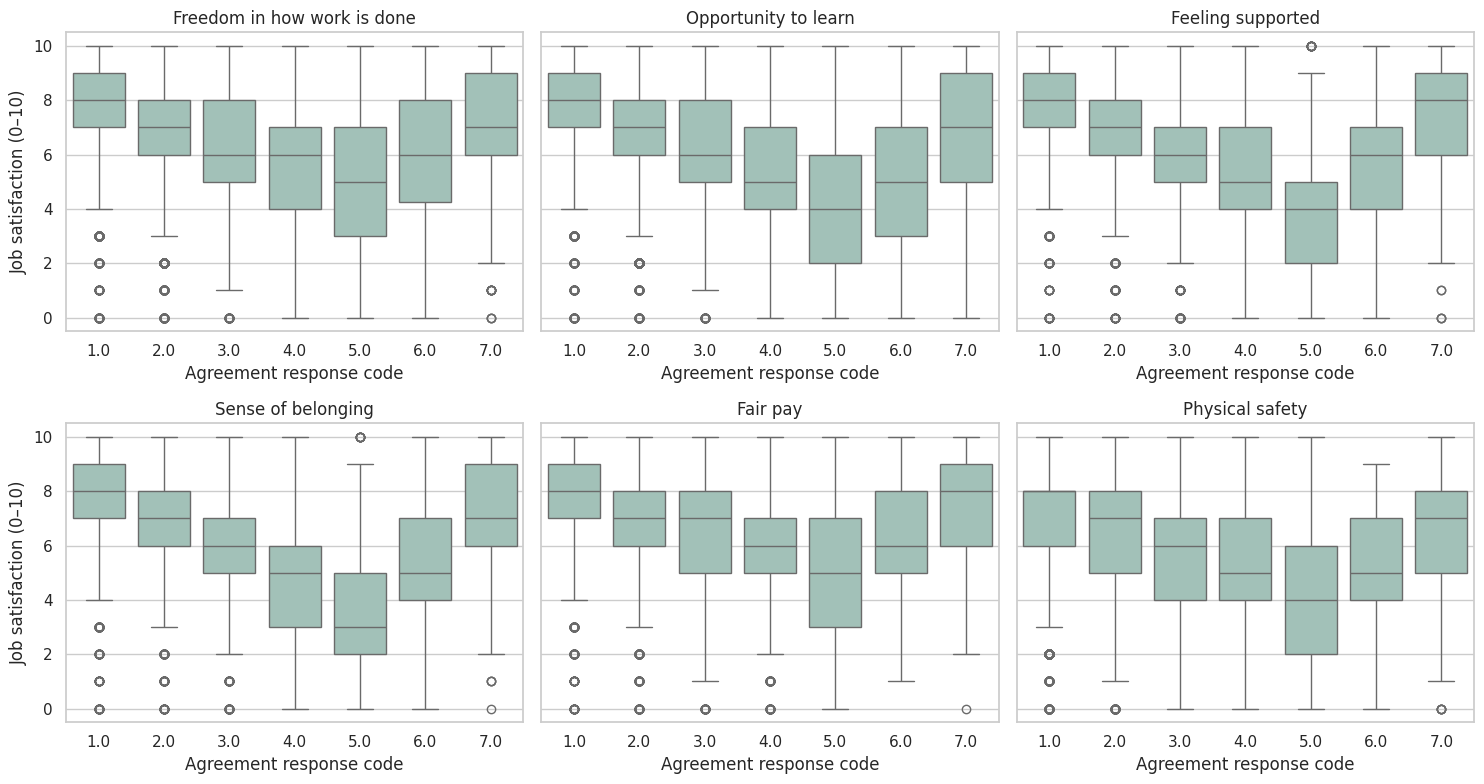

In [ ]:
job_aspects = {
    "Q33A": "Freedom in how work is done",
    "Q33C": "Opportunity to learn",
    "Q33F": "Feeling supported",
    "Q33G": "Sense of belonging",
    "Q33I": "Fair pay",
    "Q33J": "Physical safety",
}

# Q33 responses run from stronger agreement at lower numbers
# to stronger disagreement at higher numbers. Check labels in
# the codebook before interpreting any category.
rows = []

for col, description in job_aspects.items():
    subset = eda[["Q4", col]].dropna()
    rows.append({
        "aspect": description,
        "available_n": len(subset),
        "spearman_with_satisfaction": subset["Q4"].corr(
            subset[col], method="spearman"
        )
    })

aspect_summary = pd.DataFrame(rows)
display(aspect_summary.round(3))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, (col, description) in zip(axes.flat, job_aspects.items()):
    sns.boxplot(data=eda, x=col, y="Q4", ax=ax, color="#9dc6ba")
    ax.set_title(description)
    ax.set_xlabel("Agreement response code")
    ax.set_ylabel("Job satisfaction (0–10)")

plt.tight_layout()
plt.show()

In [ ]:
thresholds = []

for cutoff in [6, 7, 8, 9]:
    valid = eda["Q4"].dropna()
    thresholds.append({
        "satisfied_if_score_at_least": cutoff,
        "satisfied_n": (valid >= cutoff).sum(),
        "not_satisfied_n": (valid < cutoff).sum(),
        "satisfied_pct": 100 * (valid >= cutoff).mean()
    })

display(pd.DataFrame(thresholds).round(1))

,satisfied_if_score_at_least,satisfied_n,not_satisfied_n,satisfied_pct
0,6,14137,4244,76.9
1,7,11741,6640,63.9
2,8,7645,10736,41.6
3,9,3426,14955,18.6
